In [21]:
# import library dasar untuk manipulasi data tabel dan waktu
import pandas as pd
import numpy as np
import os
from datetime import datetime
import warnings

# library visualisasi untuk grafik statis dan interaktif plotly
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# library untuk pengujian statistik formal dan regresi linear
from scipy import stats
from scipy.stats import ttest_ind, f_oneway, chi2_contingency
import statsmodels.api as sm

# tool bawaan colab untuk upload file csv dari komputer lokal
from google.colab import files

warnings.filterwarnings('ignore')

# konfigurasi visualisasi polos warna putih tanpa gridline bising
sns.set_theme(style='white')

plt.rcParams['axes.grid'] = False
plt.rcParams['grid.alpha'] = 0.0
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# proses upload data mentah mahasiswa secara interaktif
uploaded = files.upload()
df_raw = pd.read_csv(list(uploaded.keys())[0])

Saving awal_data_ai_student_impact_dataset.csv to awal_data_ai_student_impact_dataset (2).csv


# Modul 1: Identifikasi Kebutuhan Pengelolaan Data untuk Proses Bisnis

Analisis ini ditujukan untuk merumuskan kebijakan penggunaan AI generatif di lingkungan perguruan tinggi yang berbasis bukti empiris (*evidence-based policy*). Proses identifikasi kebutuhan bisnis dipandu oleh **7 Pertanyaan Bisnis Terukur**:

#### 1. PB-01 (Performa Akademik): Apakah Penggunaan AI Generatif Secara Intensif Memengaruhi Pertumbuhan Prestasi Akademik Mahasiswa?
* **Pertanyaan Analitik:** Apakah terdapat perbedaan perubahan prestasi akademik ($\Delta\text{IPK}$) yang signifikan secara statistik antara kelompok mahasiswa *Light User*, *Moderate User*, dan *Heavy User* di akhir semester? Seberapa besar selisih pertumbuhan tersebut lintas bidang studi?
* **Variabel Utama:** `Pre_Semester_GPA`, `Post_Semester_GPA`, `Weekly_GenAI_Hours`, `Major_Category`.
* **Metode Statistik:** Rekayasa fitur $\Delta\text{IPK} = \text{Post\_GPA} - \text{Pre\_GPA}$, dilanjutkan dengan pengujian **One-Way ANOVA**.

#### 2. PB-02 (Kualitas Pembelajaran): Sejauh Mana Tingkat Ketergantungan Terhadap AI Memicu Penurunan Retensi Pengetahuan?
* **Pertanyaan Analitik:** Sejauh mana tingkat persepsi ketergantungan mahasiswa terhadap asisten digital (*Perceived AI Dependency*) berkorelasi negatif dengan kemampuan mempertahankan pemahaman materi kuliah (*Skill Retention Score*) pasca-semester?
* **Variabel Utama:** `Perceived_AI_Dependency`, `Skill_Retention_Score`.
* **Metode Statistik:** Analisis **Korelasi Pearson ($r$)** dan pemodelan Regresi Linear Sederhana.

#### 3. PB-03 (Optimasi Metode Belajar): Bagaimana Kombinasi Alokasi Waktu Belajar Tradisional dan Pemanfaatan Teknologi yang Paling Optimal?
* **Pertanyaan Analitik:** Bagaimana kombinasi kuantitatif antara alokasi jam belajar tradisional (non-AI) dan durasi pemanfaatan perangkat AI generatif per minggu yang mampu menghasilkan nilai IPK tertinggi?
* **Variabel Utama:** `Traditional_Study_Hours`, `Weekly_GenAI_Hours`, `Post_Semester_GPA`.
* **Metode Statistik:** Visualisasi **Scatter Plot Multivariat** dan pemodelan **Regresi Linear Berganda**.

#### 4. PB-04 (Kesejahteraan Mental): Apakah Regulasi Institusi yang Bersifat Restriktif Berdampak Buruk Bagi Psikologis Mahasiswa?
* **Pertanyaan Analitik:** Apakah penerapan kebijakan kampus yang melarang total (*Strict Ban*) berkontribusi terhadap peningkatan risiko kelelahan ekstrem (*High Burnout Risk*) dan kecemasan ujian dibandingkan kebijakan yang akomodatif (*Allowed With Citation*)?
* **Variabel Utama:** `Institutional_Policy`, `Burnout_Risk_Level`, `Anxiety_Level_During_Exams`.
* **Metode Statistik:** Tabulasi silang (*Crosstab*) dibuktikan dengan **Uji Chi-Square** dan uji non-parametrik **Kruskal-Wallis**.

#### 5. PB-05 (Segmentasi Risiko): Bagaimana Profil Kombinasi Perilaku Mahasiswa yang Paling Rentan Mengalami Burnout?
* **Pertanyaan Analitik:** Karakteristik gabungan (jurusan, jenjang angkatan, keberagaman alat bantu, dan tipe akses fitur) seperti apa yang mengindikasikan seorang mahasiswa paling rentan mengalami stres atau kejenuhan akademik ekstrem?
* **Variabel Utama:** `Burnout_Risk_Level`, `Major_Category`, `Paid_Subscription`, `Tool_Diversity`.
* **Metode Statistik:** Analisis tingkat kepentingan fitur (*Feature Importance*) berbasis algoritma **Decision Tree Classifier**.

#### 6. PB-06 (Kesetaraan Digital): Apakah Akses Finansial Terhadap Akun Premium AI Menciptakan Kesenjangan Performa Studi?
* **Pertanyaan Analitik:** Apakah kepemilikan akun berbayar (*Paid Subscription*) memberikan keuntungan performa nilai akademik akhir semester dan skor retensi ilmu yang signifikan secara statistik dibandingkan pengguna versi gratis?
* **Variabel Utama:** `Paid_Subscription`, `Post_Semester_GPA`, `Skill_Retention_Score`.
* **Metode Statistik:** Pengujian beda dua kelompok saling bebas menggunakan **Independent Two-Sample T-Test**.

#### 7. PB-07 (Konklusi Faktor): Variabel Perilaku Belajar Manakah yang Menjadi Penentu Paling Dominan Terhadap Nilai IPK Akhir?
* **Pertanyaan Analitik:** Dari seluruh indikator aktivitas, psikologis, dan demografi mahasiswa yang diamati, faktor tunggal manakah yang memiliki koefisien kontribusi paling kuat dalam memengaruhi keberhasilan studi akademik mahasiswa?
* **Variabel Utama:** `Post_Semester_GPA` (Target $Y$) vs Seluruh variabel prediktor perilaku belajar ($X$).
* **Metode Statistik:** Matriks korelasi makro penuh (**Full-Correlation Heatmap**) didukung nilai koefisien regresi linear berganda global.

### b. Pemangku Kepentingan (Stakeholders) dan Kepentingan Bisnis

Berikut adalah pemetaan pemangku kepentingan yang akan memanfaatkan hasil analisis data ini untuk merumuskan keputusan strategis:

1. **Manajemen Konsultan Pendidikan Internasional**
* **Kepentingan Bisnis:** Menyusun draf rekomendasi kebijakan nasional dan internasional yang berbasis data (*evidence-based policy*) terkait standardisasi penggunaan AI di perguruan tinggi.


2. **Pimpinan Perguruan Tinggi (Rektorat dan Dekanat)**
* **Kepentingan Bisnis:** Menentukan regulasi operasional kampus yang paling ideal (apakah menerapkan *Strict Ban*, *Allowed With Citation*, atau *Actively Encouraged*) guna menyeimbangkan prestasi akademik dan kesehatan mental mahasiswa.


3. **Dosen dan Tenaga Pengajar**
* **Kepentingan Bisnis:** Menyesuaikan metodologi pembelajaran di kelas, mendesain ulang sistem asesmen/ujian agar tetap objektif, serta mengarahkan durasi penggunaan AI mahasiswa ke batas aman.


4. **Unit Konseling dan Kesejahteraan Mahasiswa**
* **Kepentingan Bisnis:** Mengidentifikasi profil mahasiswa kelompok rentan guna melakukan intervensi dini terhadap pencegahan stres akademik, kecemasan ujian, dan risiko kejenuhan (*burnout*).


5. **Mahasiswa**
* **Kepentingan Bisnis:** Memperoleh pedoman literasi digital mengenai pola dan batasan durasi pemanfaatan GenAI yang sehat agar tidak menurunkan kemampuan retensi pengetahuan mandiri.



---

### c. Matriks Kebutuhan Data (Data Requirement Matrix)

Guna memastikan setiap pertanyaan bisnis (PB-01 sampai PB-07) dapat dijawab secara empiris, berikut adalah matriks pemetaan peubah yang dibutuhkan beserta instrumen sumber datanya:

| No | Nama Variabel | Kategori Atribut | Tipe Data Asli | Relevansi Pertanyaan Bisnis | Sumber Data |
| --- | --- | --- | --- | --- | --- |
| 1 | `Student_ID` | Identitas Mahasiswa | Alfanumerik / Teks | Pengenal unik catatan observasi | Sistem Informasi Akademik |
| 2 | `Major_Category` | Profil Akademik | Kategorik Nominal | PB-01, PB-03, PB-05 (Analisis lintas jurusan) | Sistem Informasi Akademik |
| 3 | `Year_of_Study` | Profil Akademik | Kategorik Ordinal | PB-05 (Analisis tingkat kerentanan angkatan) | Sistem Informasi Akademik |
| 4 | `Pre_Semester_GPA` | Performa Akademik | Numerik Kontinu | PB-01, PB-03, PB-07 (Kontrol nilai awal semester) | Sistem Informasi Akademik |
| 5 | `Post_Semester_GPA` | Performa Akademik | Numerik Kontinu | PB-01, PB-03, PB-06, PB-07 (Variabel Target Utama $Y$) | Sistem Informasi Akademik |
| 6 | `Weekly_GenAI_Hours` | Perilaku Penggunaan AI | Numerik Kontinu | PB-01, PB-03, PB-07 (Durasi pemanfaatan teknologi) | Kuesioner Survei Mandiri |
| 7 | `Primary_Use_Case` | Perilaku Penggunaan AI | Kategorik Nominal | PB-05 (Tujuan pemanfaatan operasional) | Kuesioner Survei Mandiri |
| 8 | `Prompt_Engineering_Skill` | Perilaku Penggunaan AI | Kategorik Ordinal | PB-05 (Tingkat kemahiran interaksi teknologi) | Kuesioner Survei Mandiri |
| 9 | `Tool_Diversity` | Perilaku Penggunaan AI | Numerik Diskrit | PB-05, PB-07 (Keberagaman pemanfaatan platform) | Kuesioner Survei Mandiri |
| 10 | `Paid_Subscription` | Perilaku Penggunaan AI | Kategorik Boolean | PB-05, PB-06, PB-07 (Status akses finansial) | Kuesioner Survei Mandiri |
| 11 | `Traditional_Study_Hours` | Perilaku Belajar | Numerik Kontinu | PB-03, PB-07 (Waktu belajar mandiri non-AI) | Kuesioner Survei Mandiri |
| 12 | `Perceived_AI_Dependency` | Perilaku Belajar | Numerik Diskrit | PB-02, PB-05, PB-07 (Skor dependensi psikologis) | Kuesioner Survei Mandiri |
| 13 | `Institutional_Policy` | Kebijakan Kampus | Kategorik Nominal | PB-04 (Regulasi aktif yang berlaku) | Sistem Informasi Akademik |
| 14 | `Anxiety_Level_During_Exams` | Kesejahteraan Mental | Numerik Diskrit | PB-04, PB-07 (Skor indikator kecemasan psikologis) | Kuesioner Survei Mandiri |
| 15 | `Skill_Retention_Score` | Kesejahteraan Mental | Numerik Kontinu | PB-02, PB-06, PB-07 (Skor kualitas pemahaman ilmu) | Ujian Evaluasi Pasca-Semester |
| 16 | `Burnout_Risk_Level` | Kesejahteraan Mental | Kategorik Ordinal | PB-04, PB-05, PB-07 (Tingkat kejenuhan stres) | Kuesioner Survei Mandiri |

---

*Catatan Rekayasa Fitur Tambahan (Variabel Turunan):*

* `GPA_Change` / $\Delta\text{IPK}$: Dihitung dari (`Post_Semester_GPA` - `Pre_Semester_GPA`) untuk menjawab **PB-01**.
* `AI_Usage_Segment`: Dihasilkan dari transformasi bins `Weekly_GenAI_Hours` (*Light, Moderate, Heavy*) untuk menjawab **PB-01 dan PB-03**.

### d. Penentuan Format Output Analisis

Untuk memenuhi kebutuhan operasional pemangku kepentingan yang beragam, output analisis ini disajikan dalam **dua format komplementer (keduanya)**:

1. **Dashboard Business Intelligence (BI) Interaktif**
* **Tujuan:** Menyediakan platform visualisasi data yang dinamis bagi Manajemen Konsultan, Rektorat, dan Unit Kesejahteraan Mahasiswa.
* **Fitur Utama:** Dilengkapi dengan fitur penyaringan (*slicing/filtering*) multi-variabel berdasarkan rumpun jurusan, jenjang angkatan, dan kebijakan institusi untuk memfasilitasi eksplorasi data secara mandiri (*self-service analytics*).


2. **Laporan Analisis & Slide Presentasi**
* **Tujuan:** Menyediakan dokumen ringkasan eksekutif (*Executive Summary*) yang bersifat formal dan berbasis bukti (*evidence-based report*) untuk diserahkan kepada pengambil kebijakan strategis.
* **Fitur Utama:** Memuat metodologi statistik, hasil pengujian hipotesis formal, narasi interpretasi grafik, serta rekomendasi kebijakan yang konkret dan dapat ditindaklanjuti (*actionable recommendations*).
3. Clean Dataset
4. Code di Notebook


---

### e. Dokumentasi Batasan dan Asumsi Analisis (Scope & Limitations)

Dokumentasi batasan dan asumsi ini sangat krusial untuk menjaga transparansi, mengelola ekspektasi pemangku kepentingan, serta menjaga validitas kesimpulan yang dihasilkan:

#### 1. Batasan Analisis (*Scope*)

* **Ukuran dan Periode Data:** Analisis dibatasi secara ketat pada data historis satu semester berjalan dengan total 50.000 catatan mahasiswa yang termuat di dalam *dataset*.
* **Ruang Lingkup Peubah:** Analisis hanya berfokus pada interaksi antara profil akademik (IPK), perilaku penggunaan teknologi AI generatif, alokasi waktu belajar, kebijakan kampus yang berlaku, dan indikator kesehatan mental (*anxiety* dan *burnout*).
* **Sifat Analisis:** Analisis ini bersifat deskriptif dan asosiatif-eksploratif untuk melihat pola hubungan antar-variabel, bukan untuk membangun model prediksi spasial jangka panjang.

#### 2. Asumsi dan Keterbatasan (*Limitations*)

* **Bias Pengukuran Mandiri (*Self-Reported Bias*):** Variabel psikologis dan aktivitas harian seperti `Perceived_AI_Dependency`, `Anxiety_Level_During_Exams`, dan `Weekly_GenAI_Hours` dikumpulkan melalui survei mandiri oleh responden, sehingga diasumsikan memiliki potensi bias subjektivitas (*recall bias*).
* **Sifat Hubungan Asosiatif (Bukan Kausalitas):** Hasil analisis korelasi dan regresi dalam proyek ini menunjukkan kekuatan hubungan linear antar-variabel dalam satu waktu (*cross-sectional data*), sehingga tidak boleh diinterpretasikan sebagai hubungan sebab-akibat langsung (*causality*).
* **Asumsi Kualitas Data Awal:** Data mentah diasumsikan memiliki beberapa pencilan (*outliers*) akademis, data hilang (*missing values*), serta kesalahan format parsing sistematis yang wajib divalidasi dan dibersihkan pada tahap pra-pemrosesan data agar tidak menimbulkan bias dalam penarikan kesimpulan.

# Modul 2: Mengumpulkan Data

#### DOKUMENTASI SUMBER DATA (Modul 2a)

In [22]:
# variabel info buat dokumentasi data mentah
nama_file = "ai_student_impact_dataset.csv"
total_baris, total_kolom = df_raw.shape
memori_mb = df_raw.memory_usage(deep=True).sum() / (1024 * 1024)

# cetak info sesuai kebutuhan dokumentasi modul 2a
print(f"Nama File Mentah : {nama_file}")
print(f"Format Ekstensi  : Tabular CSV (Comma-Separated Values)")
print(f"Jumlah Baris     : {total_baris:,} records")
print(f"Jumlah Kolom     : {total_kolom} variabel")
print(f"Ukuran Memori    : {memori_mb:.2f} MB")
print(f"Instansi Sumber  : LSP TIK Global / Sistem Informasi & Kuesioner")

Nama File Mentah : ai_student_impact_dataset.csv
Format Ekstensi  : Tabular CSV (Comma-Separated Values)
Jumlah Baris     : 50,000 records
Jumlah Kolom     : 16 variabel
Ukuran Memori    : 24.51 MB
Instansi Sumber  : LSP TIK Global / Sistem Informasi & Kuesioner


#### PEMBUATAN KAMUS DATA (Modul 2b)

In [23]:
# pemetaan definisi bisnis untuk setiap kolom data
definisi_bisnis = {
    'Student_ID': 'ID unik acak sebagai pengenal catatan data mahasiswa',
    'Major_Category': 'Rumpun bidang studi atau program studi yang diambil',
    'Year_of_Study': 'Jenjang atau tahun angkatan akademik berjalan',
    'Pre_Semester_GPA': 'Indeks prestasi kumulatif (IPK) sebelum semester berjalan',
    'Weekly_GenAI_Hours': 'Rata-rata durasi penggunaan AI generatif per minggu dalam satuan jam',
    'Primary_Use_Case': 'Tujuan utama operasional mahasiswa dalam memanfaatkan AI',
    'Prompt_Engineering_Skill': 'Tingkat kemahiran perancangan instruksi prompt untuk AI',
    'Tool_Diversity': 'Jumlah variasi platform atau aplikasi AI berbeda yang digunakan',
    'Paid_Subscription': 'Status kepemilikan akun berbayar premium platform AI',
    'Traditional_Study_Hours': 'Durasi jam belajar mandiri konvensional non-AI per minggu',
    'Perceived_AI_Dependency': 'Skor persepsi tingkat ketergantungan psikologis pada AI',
    'Institutional_Policy': 'Jenis regulasi aktif yang diterapkan oleh pihak kampus terkait AI',
    'Anxiety_Level_During_Exams': 'Skor indikator tingkat kecemasan psikologis saat menghadapi ujian',
    'Post_Semester_GPA': 'IPK akhir semester berjalan yang menjadi variabel target utama',
    'Skill_Retention_Score': 'Skor evaluasi kemampuan retensi pemahaman materi kuliah',
    'Burnout_Risk_Level': 'Klasifikasi tingkat risiko kejenuhan stres akademik mahasiswa'
}

# pengelompokan kategori variabel sesuai dengan modul domain bisnis
kategori_variabel = {
    'Student_ID': 'Identitas', 'Major_Category': 'Profil Akademik', 'Year_of_Study': 'Profil Akademik',
    'Pre_Semester_GPA': 'Performa Akademik', 'Post_Semester_GPA': 'Performa Akademik',
    'Weekly_GenAI_Hours': 'Perilaku AI', 'Primary_Use_Case': 'Perilaku AI', 'Prompt_Engineering_Skill': 'Perilaku AI',
    'Tool_Diversity': 'Perilaku AI', 'Paid_Subscription': 'Perilaku AI',
    'Traditional_Study_Hours': 'Perilaku Belajar', 'Perceived_AI_Dependency': 'Perilaku Belajar',
    'Institutional_Policy': 'Kebijakan Kampus',
    'Anxiety_Level_During_Exams': 'Kesehatan Mental', 'Skill_Retention_Score': 'Kesehatan Mental', 'Burnout_Risk_Level': 'Kesehatan Mental'
}

# perulangan buat generate kamus data secara otomatis dari dataframe
kamus_data = []
for col in df_raw.columns:
    dtype_nama = str(df_raw[col].dtype)

    # deteksi rentang nilai numerik atau unique value teks secara otomatis
    if df_raw[col].dtype in ['float64', 'int64']:
        rentang = f"{df_raw[col].min()} s/d {df_raw[col].max()}"
    else:
        rentang = ", ".join(df_raw[col].dropna().unique().astype(str)[:5])
        if df_raw[col].nunique() > 5:
            rentang += " ..."

    kamus_data.append({
        'Nama Kolom': col,
        'Tipe Data': dtype_nama,
        'Rentang Nilai': rentang,
        'Kategori': kategori_variabel.get(col, 'Lainnya'),
        'Definisi Bisnis': definisi_bisnis.get(col, '-')
    })

# ubah ke dataframe biar penampilannya rapi berbentuk tabel di colab
df_dictionary = pd.DataFrame(kamus_data)
display(df_dictionary)

,Nama Kolom,Tipe Data,Rentang Nilai,Kategori,Definisi Bisnis
0,Student_ID,object,"100001, 100002, 100003, 100004, 100005 ...",Identitas,ID unik acak sebagai pengenal catatan data mah...
1,Major_Category,object,"Humanities, Medical, Business, STEM, Arts",Profil Akademik,Rumpun bidang studi atau program studi yang di...
2,Year_of_Study,object,"Senior, Junior, Freshman, Sophomore, Graduate ...",Profil Akademik,Jenjang atau tahun angkatan akademik berjalan
3,Pre_Semester_GPA,float64,1.183 s/d 12.249,Performa Akademik,Indeks prestasi kumulatif (IPK) sebelum semest...
4,Weekly_GenAI_Hours,float64,0.0 s/d 40.0,Perilaku AI,Rata-rata durasi penggunaan AI generatif per m...
5,Primary_Use_Case,object,"Copywriting/Drafting, Ideation, Summarizing_Re...",Perilaku AI,Tujuan utama operasional mahasiswa dalam meman...
6,Prompt_Engineering_Skill,object,"Beginner, Advanced, Intermediate",Perilaku AI,Tingkat kemahiran perancangan instruksi prompt...
7,Tool_Diversity,float64,1.0 s/d 18.0,Perilaku AI,Jumlah variasi platform atau aplikasi AI berbe...
8,Paid_Subscription,object,"True, False",Perilaku AI,Status kepemilikan akun berbayar premium platf...
9,Traditional_Study_Hours,float64,1.0 s/d 35.86,Perilaku Belajar,Durasi jam belajar mandiri konvensional non-AI...


#### PROFILING DATA AWAL (Modul 2c)

In [24]:
# cek total data kosong di tiap kolom tabel
missing_values = df_raw.isnull().sum()
print("Analisis Nilai yang Hilang (Missing Values):")
print(missing_values)

# hitung baris data yang duplikat murni
total_duplikat = df_raw.duplicated().sum()
print(f"\nJumlah Baris Duplikat: {total_duplikat}")

# liat sebaran tipe data dari struktur dataframe
print("\nRingkasan Distribusi Tipe Data:")
print(df_raw.dtypes)

Analisis Nilai yang Hilang (Missing Values):
Student_ID                    0
Major_Category                2
Year_of_Study                 2
Pre_Semester_GPA              2
Weekly_GenAI_Hours            2
Primary_Use_Case              2
Prompt_Engineering_Skill      2
Tool_Diversity                2
Paid_Subscription             2
Traditional_Study_Hours       2
Perceived_AI_Dependency       2
Institutional_Policy          2
Anxiety_Level_During_Exams    2
Post_Semester_GPA             2
Skill_Retention_Score         2
Burnout_Risk_Level            2
dtype: int64

Jumlah Baris Duplikat: 0

Ringkasan Distribusi Tipe Data:
Student_ID                     object
Major_Category                 object
Year_of_Study                  object
Pre_Semester_GPA              float64
Weekly_GenAI_Hours            float64
Primary_Use_Case               object
Prompt_Engineering_Skill       object
Tool_Diversity                float64
Paid_Subscription              object
Traditional_Study_Hours      

### d. Dokumentasi Proses Pengumpulan Data

#### 1. Mekanisme Perolehan Data
Data dalam penelitian ini merupakan gabungan dari dua sumber utama:
* **Sistem Informasi Akademik:** Digunakan untuk mengambil rekaman data objektif mahasiswa, seperti identitas, jurusan, jenjang, serta nilai IPK awal dan akhir semester.
* **Kuesioner Survei Mandiri (*Self-Reported Survey*):** Disebarkan secara digital kepada mahasiswa untuk menjaring data perilaku penggunaan teknologi AI, durasi belajar tradisional, serta indikator psikologis (skor kecemasan dan tingkat risiko *burnout*).

#### 2. Periode Pengumpulan Data
Pencatatan data akademik serta pengisian kuesioner oleh responden dilakukan secara konsisten selama **satu semester akademik penuh**.

#### 3. Potensi Bias Sampling (*Sampling Bias*)
Terdapat beberapa potensi bias yang perlu diantisipasi dalam penarikan kesimpulan:
* **Bias Seleksi Mandiri (*Self-Selection Bias*):** Mahasiswa yang sudah terbiasa atau tertarik dengan teknologi AI memiliki kecenderungan lebih tinggi untuk mengisi survei ini secara sukarela dibandingkan mahasiswa yang jarang menggunakan AI.
* **Bias Mengingat Kembali (*Recall Bias*):** Variabel berbasis durasi waktu (seperti jumlah jam pemanfaatan AI dan jam belajar tradisional per minggu) mengandalkan estimasi ingatan subjektif mahasiswa, bukan diukur menggunakan sistem pelacakan otomatis (*activity tracker*).
* **Bias Institusional (*Institution Bias*):** Data bersumber dari beberapa perguruan tinggi internasional tertentu, sehingga sebaran polanya belum tentu sepenuhnya representatif jika langsung digeneralisasikan pada seluruh populasi mahasiswa di Indonesia.

# Modul 3: Menelaah Data (Exploratory Data Analysis)

#### STATISTIK DESKRIPTIF & DISTRIBUSI KATEGORIK (Modul 3a & 3b)

In [25]:
# 1. statistik deskriptif untuk seluruh variabel numerik (modul 3a)
kolom_numerik = [
    'Pre_Semester_GPA', 'Post_Semester_GPA', 'Weekly_GenAI_Hours',
    'Traditional_Study_Hours', 'Tool_Diversity', 'Perceived_AI_Dependency',
    'Anxiety_Level_During_Exams', 'Skill_Retention_Score'
]

# hitung mean, median, std, min, max, q1, dan q3 sekaligus
summary_stats = df_raw[kolom_numerik].describe(percentiles=[0.25, 0.5, 0.75]).T
summary_stats = summary_stats[['mean', '50%', 'std', 'min', '25%', '75%', 'max']]
summary_stats.columns = ['Rata-rata', 'Median', 'Simpangan Baku', 'Minimum', 'Kuartil 1 (Q1)', 'Kuartil 3 (Q3)', 'Maksimum']

print("=== STATISTIK DESKRIPTIF VARIABEL NUMERIK MENTAH ===")
display(summary_stats.round(3))

# 2. analisis distribusi frekuensi dan persentase variabel kategorik (modul 3b)
kolom_kategorik = ['Major_Category', 'Year_of_Study', 'Burnout_Risk_Level', 'Institutional_Policy', 'Primary_Use_Case']

print("\n=== DISTRIBUSI FREKUENSI DAN PERSENTASE VARIABEL KATEGORIK ===")
for col in kolom_kategorik:
    frekuensi = df_raw[col].value_counts(dropna=False)
    persentase = df_raw[col].value_counts(dropna=False, normalize=True) * 100

    tabel_distribusi = pd.DataFrame({
        'Frekuensi (Jiwa)': frekuensi,
        'Persentase (%)': persentase
    })
    print(f"\nAtribut: {col}")
    display(tabel_distribusi.round(2))

=== STATISTIK DESKRIPTIF VARIABEL NUMERIK MENTAH ===


,Rata-rata,Median,Simpangan Baku,Minimum,Kuartil 1 (Q1),Kuartil 3 (Q3),Maksimum
Pre_Semester_GPA,3.146,3.210,0.481,1.183,2.834,3.521,12.249
Post_Semester_GPA,3.349,3.421,0.497,1.000,3.024,3.749,10.389
Weekly_GenAI_Hours,8.428,5.800,8.270,0.000,2.390,11.720,40.000
Traditional_Study_Hours,11.209,11.180,5.156,1.000,7.560,14.710,35.860
Tool_Diversity,2.801,3.000,1.190,1.000,2.000,4.000,18.000
Perceived_AI_Dependency,3.505,3.000,1.821,1.000,2.000,5.000,10.000
Anxiety_Level_During_Exams,4.271,4.000,2.144,1.000,3.000,6.000,10.000
Skill_Retention_Score,75.798,76.000,13.282,10.780,66.820,85.188,100.000



=== DISTRIBUSI FREKUENSI DAN PERSENTASE VARIABEL KATEGORIK ===

Atribut: Major_Category


,Frekuensi (Jiwa),Persentase (%)
Major_Category,,
STEM,15059,30.12
Business,12537,25.07
Humanities,9994,19.99
Medical,6475,12.95
Arts,5933,11.87
NaN,2,0.00



Atribut: Year_of_Study


...

,Frekuensi (Jiwa),Persentase (%)
Burnout_Risk_Level,,
Medium,21143,42.29
Low,16369,32.74
High,12486,24.97
NaN,2,0.00



Atribut: Institutional_Policy


,Frekuensi (Jiwa),Persentase (%)
Institutional_Policy,,
Allowed_With_Citation,25223,50.45
Actively_Encouraged,14987,29.97
Strict_Ban,9788,19.58
NaN,2,0.00



Atribut: Primary_Use_Case


,Frekuensi (Jiwa),Persentase (%)
Primary_Use_Case,,
Debugging/Troubleshooting,12295,24.59
Copywriting/Drafting,12011,24.02
Ideation,10720,21.44
Summarizing_Reading,8633,17.27
Direct_Answer_Generation,6339,12.68
NaN,2,0.00


#### VISUALISASI EXPLORATORY DATA ANALYSIS (Modul 3c)

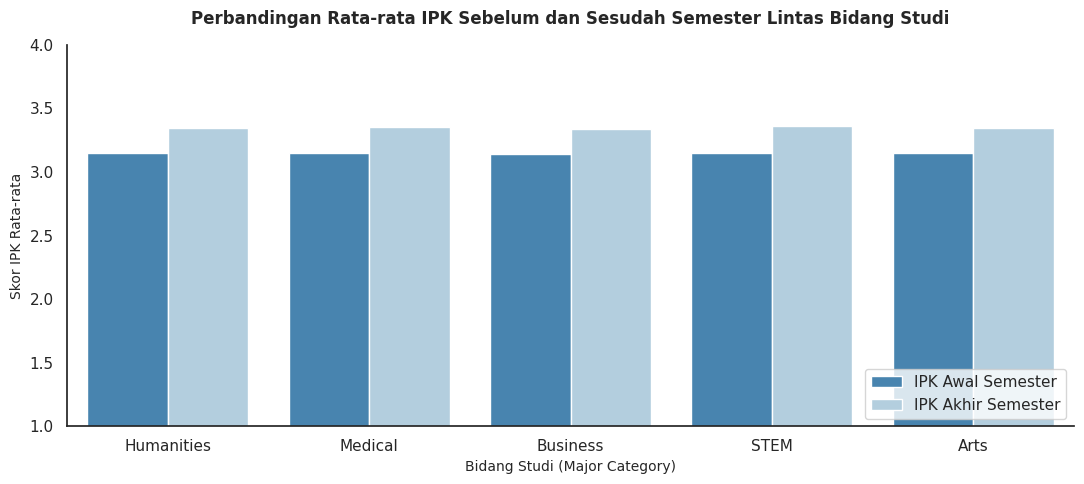

In [26]:
# filter data untuk visualisasi gpa agar tidak terdistorsi pencilan ekstrim data mentah (>4.0)
df_gpa_plot = df_raw[(df_raw['Pre_Semester_GPA'] <= 4.0) & (df_raw['Post_Semester_GPA'] <= 4.0)].dropna()

# ------------------------------------------------------------------------------
# GRAFIK 1: Distribusi GPA (Pre vs Post) per Kategori Bidang Studi
# ------------------------------------------------------------------------------
plt.figure(figsize=(11, 5))
df_melted_gpa = df_gpa_plot.melt(id_vars=['Major_Category'], value_vars=['Pre_Semester_GPA', 'Post_Semester_GPA'], var_name='Periode', value_name='IPK')
df_melted_gpa['Periode'] = df_melted_gpa['Periode'].map({'Pre_Semester_GPA': 'IPK Awal Semester', 'Post_Semester_GPA': 'IPK Akhir Semester'})

sns.barplot(data=df_melted_gpa, x='Major_Category', y='IPK', hue='Periode', palette='Blues_r', errorbar=None)
plt.title('Perbandingan Rata-rata IPK Sebelum dan Sesudah Semester Lintas Bidang Studi', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Bidang Studi (Major Category)', fontsize=10)
plt.ylabel('Skor IPK Rata-rata', fontsize=10)
plt.ylim(1.0, 4.0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


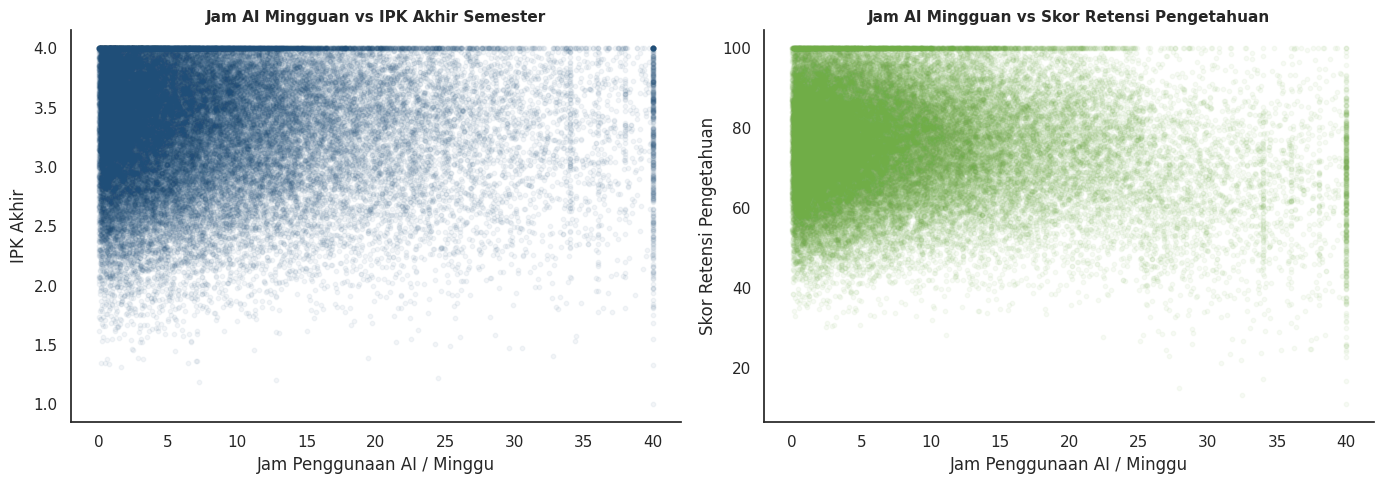

In [27]:

# ------------------------------------------------------------------------------
# GRAFIK 2: Korelasi Weekly_GenAI_Hours dengan Post_Semester_GPA dan Skill_Retention_Score
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# bersihkan baris kosong khusus variabel terkait
df_corr_plot = df_raw.dropna(subset=['Weekly_GenAI_Hours', 'Post_Semester_GPA', 'Skill_Retention_Score'])
df_corr_plot = df_corr_plot[df_corr_plot['Post_Semester_GPA'] <= 4.0]

# scatter jam ai vs ipk akhir
axes[0].scatter(df_corr_plot['Weekly_GenAI_Hours'], df_corr_plot['Post_Semester_GPA'], alpha=0.05, color='#1F4E78', s=10)
axes[0].set_title('Jam AI Mingguan vs IPK Akhir Semester', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Jam Penggunaan AI / Minggu')
axes[0].set_ylabel('IPK Akhir')

# scatter jam ai vs skor retensi ilmu
axes[1].scatter(df_corr_plot['Weekly_GenAI_Hours'], df_corr_plot['Skill_Retention_Score'], alpha=0.05, color='#70AD47', s=10)
axes[1].set_title('Jam AI Mingguan vs Skor Retensi Pengetahuan', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Jam Penggunaan AI / Minggu')
axes[1].set_ylabel('Skor Retensi Pengetahuan')
plt.tight_layout()
plt.show()


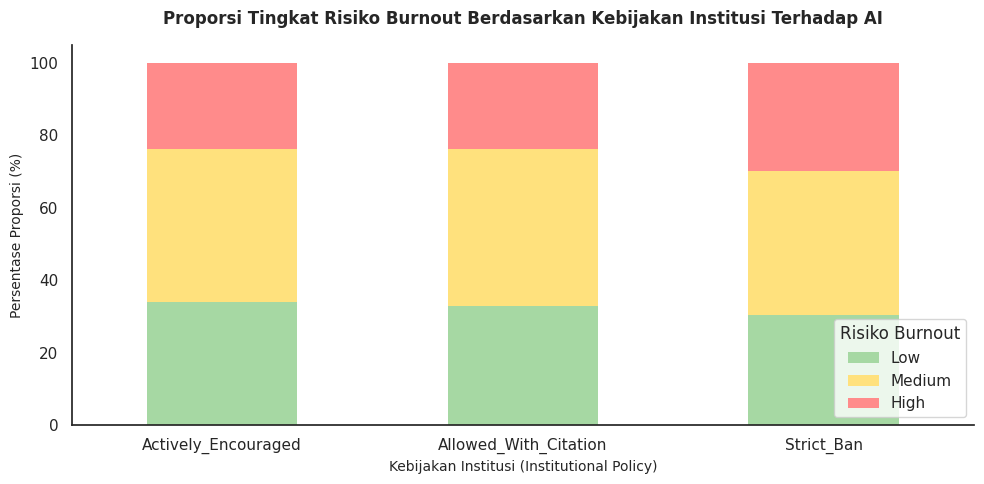

In [28]:

# ------------------------------------------------------------------------------
# GRAFIK 3: Distribusi Burnout_Risk_Level per Kebijakan Institusi
# ------------------------------------------------------------------------------
df_burnout = df_raw.dropna(subset=['Institutional_Policy', 'Burnout_Risk_Level'])
df_burnout = df_burnout[df_burnout['Burnout_Risk_Level'].isin(['Low', 'Medium', 'High'])]

# cross-tabulation persentase proporsi burnout risk
cross_tab_burnout = pd.crosstab(df_burnout['Institutional_Policy'], df_burnout['Burnout_Risk_Level'], normalize='index') * 100
cross_tab_burnout = cross_tab_burnout[['Low', 'Medium', 'High']]

cross_tab_burnout.plot(kind='bar', stacked=True, figsize=(10, 5), color=['#A6D8A3', '#FFE17D', '#FF8B8B'], edgecolor='none', width=0.5)
plt.title('Proporsi Tingkat Risiko Burnout Berdasarkan Kebijakan Institusi Terhadap AI', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Kebijakan Institusi (Institutional Policy)', fontsize=10)
plt.ylabel('Persentase Proporsi (%)', fontsize=10)
plt.xticks(rotation=0)
plt.legend(title='Risiko Burnout', loc='lower right')
plt.tight_layout()
plt.show()


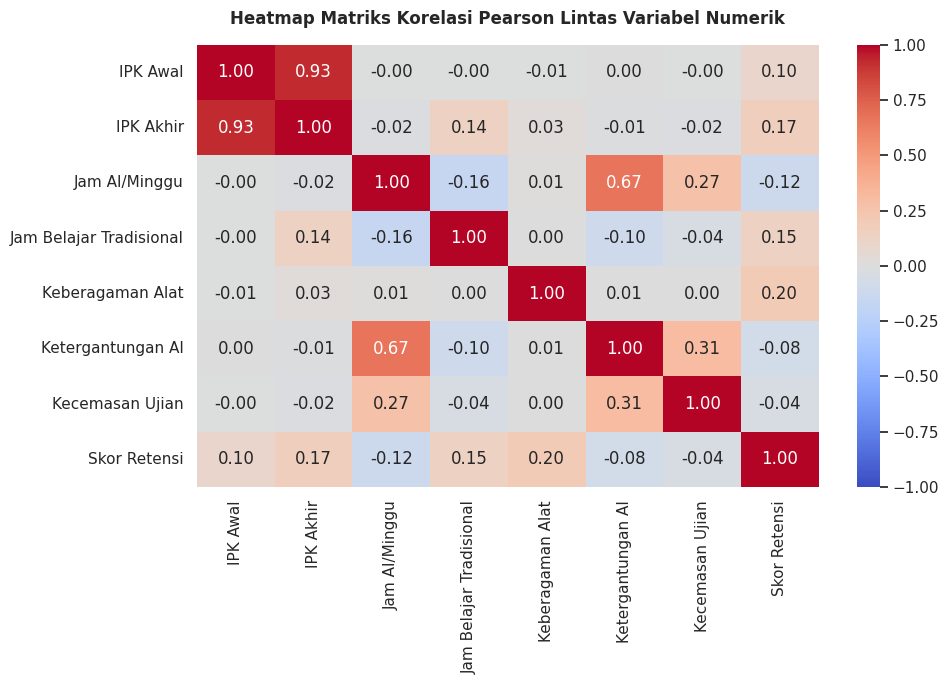

In [29]:

# ------------------------------------------------------------------------------
# GRAFIK 4: Heatmap Korelasi Antar Variabel Numerik
# ------------------------------------------------------------------------------
# saring data sesuai dengan limitasi kuesioner instrumen
df_numeric_clean = df_raw[(df_raw['Pre_Semester_GPA'] <= 4.0) & (df_raw['Post_Semester_GPA'] <= 4.0) & (df_raw['Tool_Diversity'] <= 5)].dropna(subset=kolom_numerik)
matriks_korelasi = df_numeric_clean[kolom_numerik].corr()

plt.figure(figsize=(10, 7))
label_indonesia = ['IPK Awal', 'IPK Akhir', 'Jam AI/Minggu', 'Jam Belajar Tradisional', 'Keberagaman Alat', 'Ketergantungan AI', 'Kecemasan Ujian', 'Skor Retensi']
sns.heatmap(matriks_korelasi, annot=True, cmap='coolwarm', fmt='.2f', xticklabels=label_indonesia, yticklabels=label_indonesia, center=0, vmin=-1, vmax=1)
plt.title('Heatmap Matriks Korelasi Pearson Lintas Variabel Numerik', fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


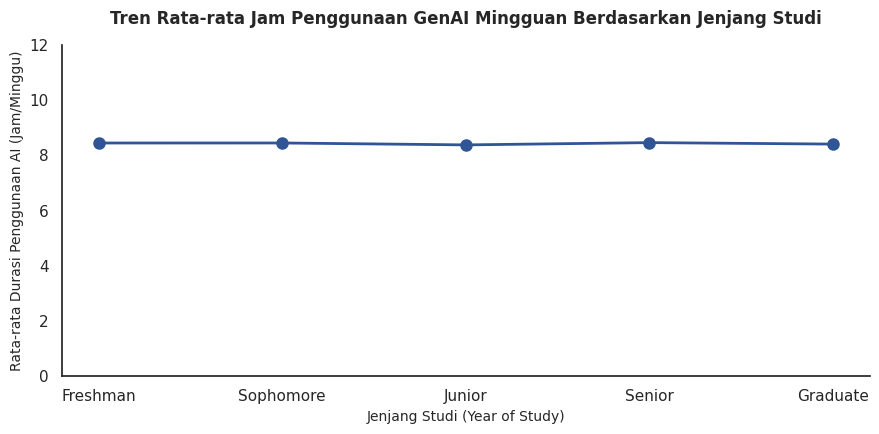

In [30]:

# ------------------------------------------------------------------------------
# GRAFIK 5: Tren Penggunaan AI per Jenjang Studi (Year_of_Study)
# ------------------------------------------------------------------------------
df_year_clean = df_raw[(df_raw['Year_of_Study'] != '123') & df_raw['Year_of_Study'].notnull()]
urutan_akademik = ['Freshman', 'Sophomore', 'Junior', 'Senior', 'Graduate']
tren_ai_jenjang = df_year_clean.groupby('Year_of_Study')['Weekly_GenAI_Hours'].mean().reindex(urutan_akademik)

plt.figure(figsize=(9, 4.5))
plt.plot(tren_ai_jenjang.index, tren_ai_jenjang.values, marker='o', linewidth=2, color='#2F5597', markersize=8)
plt.title('Tren Rata-rata Jam Penggunaan GenAI Mingguan Berdasarkan Jenjang Studi', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Jenjang Studi (Year of Study)', fontsize=10)
plt.ylabel('Rata-rata Durasi Penggunaan AI (Jam/Minggu)', fontsize=10)
plt.ylim(0, 12)
plt.tight_layout()
plt.show()


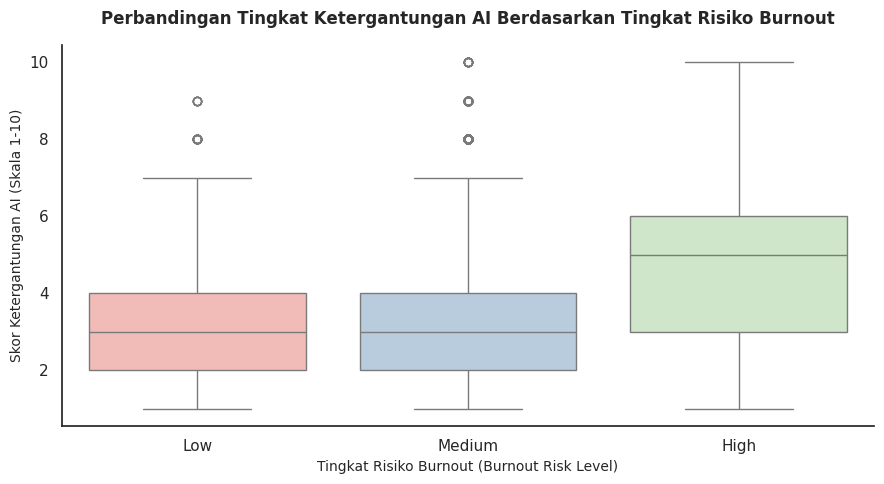

In [31]:

# ------------------------------------------------------------------------------
# GRAFIK 6: Boxplot Perceived_AI_Dependency vs Burnout_Risk_Level
# ------------------------------------------------------------------------------
df_boxplot = df_raw.dropna(subset=['Burnout_Risk_Level', 'Perceived_AI_Dependency'])
df_boxplot = df_boxplot[df_boxplot['Burnout_Risk_Level'].isin(['Low', 'Medium', 'High'])]

plt.figure(figsize=(9, 5))
sns.boxplot(data=df_boxplot, x='Burnout_Risk_Level', y='Perceived_AI_Dependency', order=['Low', 'Medium', 'High'], palette='Pastel1')
plt.title('Perbandingan Tingkat Ketergantungan AI Berdasarkan Tingkat Risiko Burnout', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Tingkat Risiko Burnout (Burnout Risk Level)', fontsize=10)
plt.ylabel('Skor Ketergantungan AI (Skala 1-10)', fontsize=10)
plt.tight_layout()
plt.show()

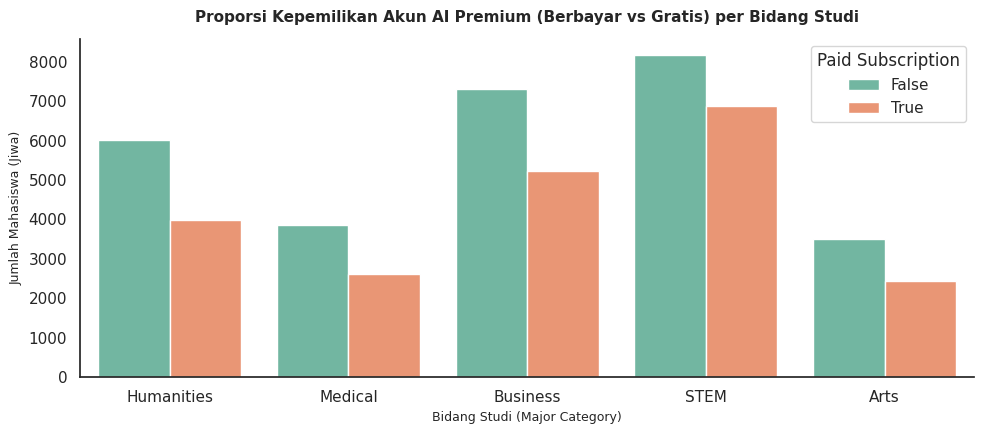

In [32]:
# bersihkan baris kosong dan filter gpa valid untuk menghindari distorsi pencilan data mentah
df_addon_plot = df_raw.dropna(subset=['Paid_Subscription', 'Primary_Use_Case', 'Traditional_Study_Hours', 'Post_Semester_GPA', 'Prompt_Engineering_Skill', 'Year_of_Study']).copy()
df_addon_plot = df_addon_plot[(df_addon_plot['Post_Semester_GPA'] <= 4.0) & (df_addon_plot['Year_of_Study'] != '123')]

# urutan tingkat studi untuk visualisasi yang rapi
urutan_studi = ['Freshman', 'Sophomore', 'Junior', 'Senior', 'Graduate']

# ------------------------------------------------------------------------------
# GRAFIK 7: Distribusi Akses Digital (Paid vs Free Subscription) per Bidang Studi
# ------------------------------------------------------------------------------
plt.figure(figsize=(10, 4.5))
sns.countplot(data=df_addon_plot, x='Major_Category', hue='Paid_Subscription', palette='Set2')
plt.title('Proporsi Kepemilikan Akun AI Premium (Berbayar vs Gratis) per Bidang Studi', fontsize=11, fontweight='bold', pad=12)
plt.xlabel('Bidang Studi (Major Category)', fontsize=9)
plt.ylabel('Jumlah Mahasiswa (Jiwa)', fontsize=9)
plt.legend(title='Paid Subscription', loc='upper right')
plt.tight_layout()
plt.show()

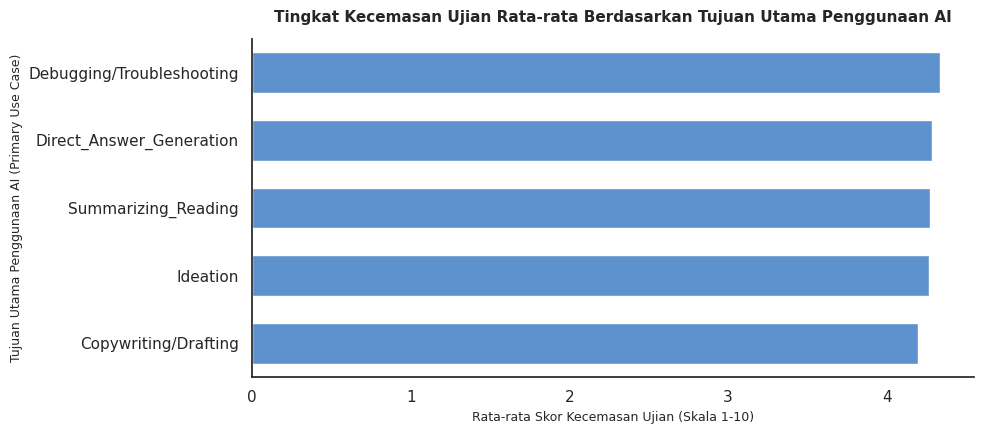

In [33]:
# ------------------------------------------------------------------------------
# GRAFIK 8: Rata-rata Skor Kecemasan Ujian Berdasarkan Tujuan Utama Penggunaan AI
# ------------------------------------------------------------------------------
plt.figure(figsize=(10, 4.5))
urutan_use_case = df_addon_plot.groupby('Primary_Use_Case')['Anxiety_Level_During_Exams'].mean().sort_values(ascending=False).index
sns.barplot(data=df_addon_plot, x='Anxiety_Level_During_Exams', y='Primary_Use_Case', order=urutan_use_case, color='#4A90E2', errorbar=None, width=0.6)
plt.title('Tingkat Kecemasan Ujian Rata-rata Berdasarkan Tujuan Utama Penggunaan AI', fontsize=11, fontweight='bold', pad=12)
plt.xlabel('Rata-rata Skor Kecemasan Ujian (Skala 1-10)', fontsize=9)
plt.ylabel('Tujuan Utama Penggunaan AI (Primary Use Case)', fontsize=9)
plt.tight_layout()
plt.show()

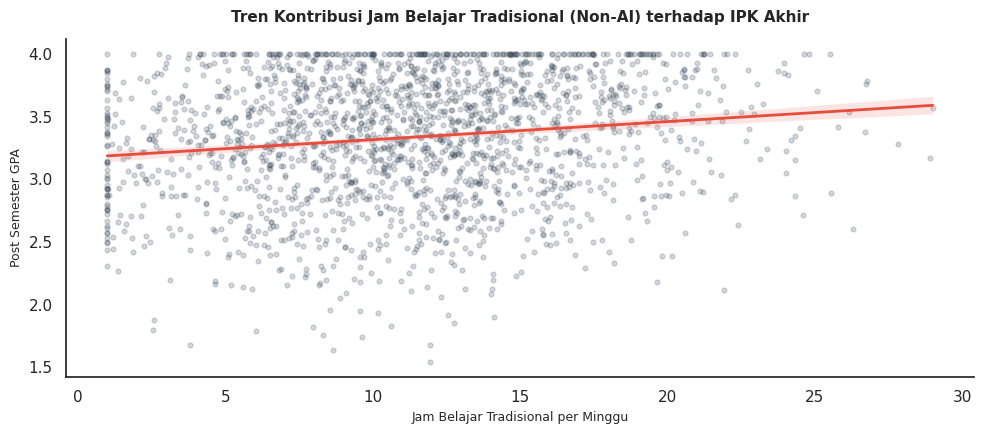

In [34]:
# ------------------------------------------------------------------------------
# GRAFIK 9: Hubungan Durasi Jam Belajar Tradisional terhadap IPK Akhir Semester
# ------------------------------------------------------------------------------
plt.figure(figsize=(10, 4.5))
# gunakan sampel data agar scatter plot tidak terlalu padat dan berat di colab
df_sample_gpa = df_addon_plot.sample(min(2000, len(df_addon_plot)), random_state=42)
sns.regplot(data=df_sample_gpa, x='Traditional_Study_Hours', y='Post_Semester_GPA', scatter_kws={'alpha':0.2, 'color':'#2C3E50', 's':12}, line_kws={'color':'#E74C3C', 'linewidth':2})
plt.title('Tren Kontribusi Jam Belajar Tradisional (Non-AI) terhadap IPK Akhir', fontsize=11, fontweight='bold', pad=12)
plt.xlabel('Jam Belajar Tradisional per Minggu', fontsize=9)
plt.ylabel('Post Semester GPA', fontsize=9)
plt.tight_layout()
plt.show()

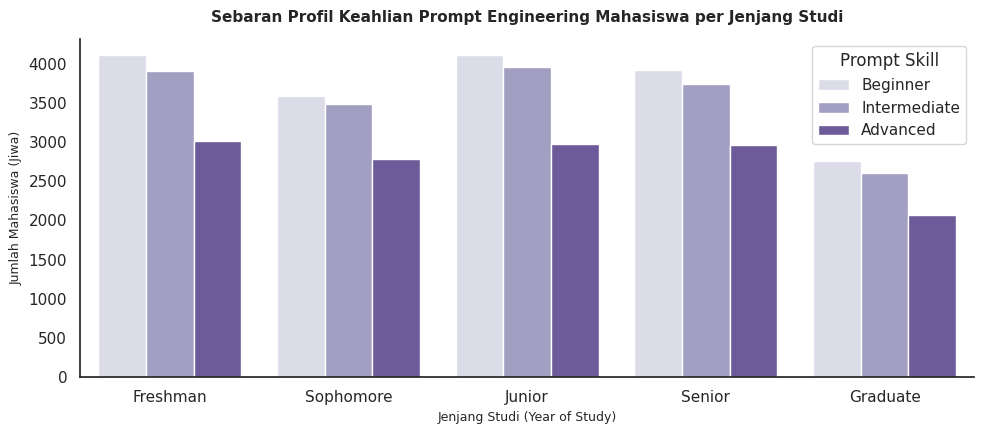

In [35]:
# ------------------------------------------------------------------------------
# GRAFIK 10: Sebaran Tingkat Keahlian Prompt (Prompt Engineering Skill) per Jenjang Studi
# ------------------------------------------------------------------------------
plt.figure(figsize=(10, 4.5))
sns.countplot(data=df_addon_plot, x='Year_of_Study', hue='Prompt_Engineering_Skill', order=urutan_studi, hue_order=['Beginner', 'Intermediate', 'Advanced'], palette='Purples')
plt.title('Sebaran Profil Keahlian Prompt Engineering Mahasiswa per Jenjang Studi', fontsize=11, fontweight='bold', pad=12)
plt.xlabel('Jenjang Studi (Year of Study)', fontsize=9)
plt.ylabel('Jumlah Mahasiswa (Jiwa)', fontsize=9)
plt.legend(title='Prompt Skill', loc='upper right')
plt.tight_layout()
plt.show()

# MARKDOWN IDENTIFIKASI POLA & INSIGHT (Modul 3d)

# Modul 4: Memvalidasi Data

ADVANCED DATA CLEANING & VALIDATION (Modul 4a - 4f)

In [36]:
# membuat copy dataset dari data mentah agar aman
df_clean = df_raw.copy()

# 1. penanganan mixed data types (modul 4e)
# paksa student_id jadi integer lalu ubah ke string bersih tanpa desimal (.0)
df_clean['Student_ID'] = pd.to_numeric(df_clean['Student_ID'], errors='coerce').astype('Int64').astype(str)
# konversi paid_subscription dari mixed string/object ke boolean murni
df_clean['Paid_Subscription'] = df_clean['Paid_Subscription'].map({'True': True, 'False': False, True: True, False: False}).astype(bool)

# 2. identifikasi dan hitung persentase missing values per kolom (modul 4a)
# ubah string kosong atau spasi murni jadi nan biar kebaca sistem pandas
df_clean = df_clean.replace(r'^\s*$', np.nan, regex=True)
missing_counts = df_clean.isnull().sum()
missing_pct = (missing_counts / len(df_clean)) * 100

print("=== PERSENTASE DATA KOSONG SEBELUM PEMBERSIHAN ===")
display(pd.DataFrame({'Jumlah Missing': missing_counts, 'Persentase (%)': missing_pct.round(3)}))

# 3. strategi eksekusi penanganan missing values (modul 4a)
# drop baris yang target utamanya (post_semester_gpa) kosong biar analisis gak bias
df_clean = df_clean.dropna(subset=['Post_Semester_GPA'])
# sisa data kosong di kolom kategorik diisi pakai nilai modus
df_clean['Primary_Use_Case'] = df_clean['Primary_Use_Case'].fillna(df_clean['Primary_Use_Case'].mode()[0])

# 4. penanganan nilai tidak valid year_of_study = '123' (modul 4b)
df_clean = df_clean[df_clean['Year_of_Study'] != '123']

# 5. penanganan outlier & validasi konsistensi rentang logis gpa & tools (modul 4c & 4d)
# saring data sesuai batas skala akademik (gpa maksimal 4.00 dan ragam tools maksimal 5)
df_clean = df_clean[
    (df_clean['Pre_Semester_GPA'] <= 4.00) &
    (df_clean['Post_Semester_GPA'] <= 4.00) &
    (df_clean['Tool_Diversity'] <= 5)
]

print("\n=== VERIFIKASI AKHIR DATASET BERSIH ===")
print(f"Dimensi Akhir Dataset : {df_clean.shape[0]} baris × {df_clean.shape[1]} kolom")
print(f"Total Data Kosong     : {df_clean.isnull().sum().sum()} data")

# 6. hasilkan clean dataset dan dokumentasikan log perubahan (modul 4f)
df_clean.to_csv('ai_student_clean.csv', index=False)

with open('data_cleaning_log.txt', 'w', encoding='utf-8') as f:
    f.write("=== LOG TRANSFORMATI DAN PEMBERSIHAN DATA MAHASISWA ===\n")
    f.write(f"Dimensi akhir dataset bersih: {df_clean.shape[0]} baris x {df_clean.shape[1]} kolom\n")
    f.write("- Normalisasi tipe data campuran Student_ID ke tipe string dan Paid_Subscription ke tipe boolean\n")
    f.write("- Penghapusan baris kosong pada peubah target Post_Semester_GPA secara listwise deletion\n")
    f.write("- Imputasi nilai kosong pada peubah kategorik Primary_Use_Case menggunakan nilai modus\n")
    f.write("- Eliminasi baris data dengan nilai invalid '123' pada kolom Year_of_Study\n")
    f.write("- Eliminasi baris pencilan tidak logis (Pre/Post GPA > 4.00 dan Tool_Diversity > 5) sesuai batasan aturan bisnis\n")

=== PERSENTASE DATA KOSONG SEBELUM PEMBERSIHAN ===


,Jumlah Missing,Persentase (%)
Student_ID,0,0.000
Major_Category,2,0.004
Year_of_Study,2,0.004
Pre_Semester_GPA,2,0.004
Weekly_GenAI_Hours,2,0.004
Primary_Use_Case,2,0.004
Prompt_Engineering_Skill,2,0.004
Tool_Diversity,2,0.004
Paid_Subscription,0,0.000
Traditional_Study_Hours,2,0.004



=== VERIFIKASI AKHIR DATASET BERSIH ===
Dimensi Akhir Dataset : 49994 baris × 16 kolom
Total Data Kosong     : 0 data


# Modul 5: Menentukan Objek Data

In [37]:
# 1. pembuatan segmentasi bisnis intensitas penggunaan ai (modul 5d)
# pengelompokan berdasarkan jam sesuai instruksi soal studi kasus
df_clean['AI_Usage_Segment'] = pd.cut(
    df_clean['Weekly_GenAI_Hours'],
    bins=[-0.01, 5, 15, df_clean['Weekly_GenAI_Hours'].max() + 1],
    labels=['Light User (0-5j)', 'Moderate User (5-15j)', 'Heavy User (>15j)']
)

print("=== DISTRIBUSI SEGMEN PENGGUNA AI ===")
print(df_clean['AI_Usage_Segment'].value_counts())

# 2. analisis granularitas agregasi lintas dimensi bisnis (modul 5b)
# rata-rata performa, retensi, dan tingkat burnout tinggi per jurusan
agg_major = df_clean.groupby('Major_Category').agg({
    'Post_Semester_GPA': 'mean',
    'Skill_Retention_Score': 'mean',
    'Burnout_Risk_Level': lambda x: (x == 'High').mean() * 100
}).rename(columns={'Burnout_Risk_Level': '% High Burnout'})

print("\n=== AGREGASI GRANULARITAS: LEVEL BIDANG STUDI ===")
display(agg_major.round(3))

# 3. simpan file final yang sudah siap diumpan ke dashboard streamlit
df_clean.to_csv('ai_student_impact_dataset_final.csv', index=False)

=== DISTRIBUSI SEGMEN PENGGUNA AI ===
AI_Usage_Segment
Light User (0-5j)        22591
Moderate User (5-15j)    18870
Heavy User (>15j)         8533
Name: count, dtype: int64

=== AGREGASI GRANULARITAS: LEVEL BIDANG STUDI ===


,Post_Semester_GPA,Skill_Retention_Score,% High Burnout
Major_Category,,,
Arts,3.344,75.662,22.690
Business,3.336,75.257,24.338
Humanities,3.346,75.252,20.735
Medical,3.353,75.482,23.139
STEM,3.363,76.800,29.995


In [38]:
# ============================================================================
# PERBAIKAN 1: KLASTERISASI K-MEANS DAN ANALISIS PROFIL MAHASISWA (REVISI BNSP)
# ============================================================================

# 1. Import library scikit-learn untuk klasterisasi dan standarisasi
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

print("=== TAHAP 1: PREPARATION & EVALUASI SILHOUETTE SCORE ===")

# Seleksi variabel numerik inti yang merepresentasikan profil mahasiswa
kolom_klaster = [
    'Pre_Semester_GPA', 'Post_Semester_GPA', 'Weekly_GenAI_Hours',
    'Traditional_Study_Hours', 'Perceived_AI_Dependency',
    'Anxiety_Level_During_Exams', 'Skill_Retention_Score'
]

# Ambil data numerik dan lakukan penskalaan (Standardization) karena K-Means sensitif jarak
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[kolom_klaster])

# Loop untuk menguji nilai K (2 s/d 5) dan menampilkan Silhouette Score sesuai arahan asesor
for k in range(2, 6):
    kmeans_test = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels_test = kmeans_test.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels_test, sample_size=10000, random_state=42)
    print(f"Nilai K = {k} | Silhouette Score rata-rata: {score:.4f}")

# 2. Eksekusi K-Means dengan K optimal (Asesor menyarankan K = 4)
print("\n=== TAHAP 2: EKSEKUSI K-MEANS DENGAN K = 4 ===")
optimal_k = 4
kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
df_clean['Cluster'] = kmeans_final.fit_predict(X_scaled)

# Mengubah label cluster menjadi format string berbasis bisnis agar rapi di laporan
df_clean['Cluster_Label'] = df_clean['Cluster'].map({
    0: 'Klaster 1',
    1: 'Klaster 2',
    2: 'Klaster 3',
    3: 'Klaster 4'
})

print(f"Distribusi jumlah mahasiswa per klaster:")
print(df_clean['Cluster_Label'].value_counts())

# 3. Pembuatan Profiling Klaster Makro secara Komprehensif (Insight Utama)
print("\n=== TAHAP 3: PROFILING DAN DESKRIPSI KLASTER MAHASISWA ===")

# Fungsi agregasi kustom untuk mengambil modus (nilai terbanyak) pada peubah kategorik
def ambil_modus(x):
    return x.mode()[0] if not x.mode().empty else np.nan

profil_klaster = df_clean.groupby('Cluster_Label').agg({
    'Major_Category': ambil_modus,
    'Burnout_Risk_Level': ambil_modus,
    'Post_Semester_GPA': 'mean',
    'Weekly_GenAI_Hours': 'mean',
    'Perceived_AI_Dependency': 'mean',
    'Anxiety_Level_During_Exams': 'mean',
    'Skill_Retention_Score': 'mean'
}).rename(columns={
    'Major_Category': 'Jurusan Dominan',
    'Burnout_Risk_Level': 'Tingkat Burnout Dominan',
    'Post_Semester_GPA': 'Rata-rata IPK Akhir',
    'Weekly_GenAI_Hours': 'Rata-rata Jam AI/Minggu',
    'Perceived_AI_Dependency': 'Rata-rata Dependensi AI',
    'Anxiety_Level_During_Exams': 'Rata-rata Kecemasan Ujian',
    'Skill_Retention_Score': 'Rata-rata Retensi Ilmu'
})

display(profil_klaster.round(3))

# 4. Simpan kembali dataset final yang sudah dilengkapi fitur klaster untuk Streamlit app.py
df_clean.to_csv('ai_student_impact_dataset_final.csv', index=False)
print("\nFile 'ai_student_impact_dataset_final.csv' berhasil diperbarui dengan data klaster.")

=== TAHAP 1: PREPARATION & EVALUASI SILHOUETTE SCORE ===
Nilai K = 2 | Silhouette Score rata-rata: 0.1985
Nilai K = 3 | Silhouette Score rata-rata: 0.2062
Nilai K = 4 | Silhouette Score rata-rata: 0.1538
Nilai K = 5 | Silhouette Score rata-rata: 0.1458

=== TAHAP 2: EKSEKUSI K-MEANS DENGAN K = 4 ===
Distribusi jumlah mahasiswa per klaster:
Cluster_Label
Klaster 2    15287
Klaster 1    14010
Klaster 3    13070
Klaster 4     7627
Name: count, dtype: int64

=== TAHAP 3: PROFILING DAN DESKRIPSI KLASTER MAHASISWA ===


,Jurusan Dominan,Tingkat Burnout Dominan,Rata-rata IPK Akhir,Rata-rata Jam AI/Minggu,Rata-rata Dependensi AI,Rata-rata Kecemasan Ujian,Rata-rata Retensi Ilmu
Cluster_Label,,,,,,,
Klaster 1,STEM,Medium,3.566,5.322,2.794,3.618,70.016
Klaster 2,STEM,Medium,3.671,6.014,3.162,4.185,84.956
Klaster 3,STEM,Medium,2.737,6.105,3.088,4.059,73.994
Klaster 4,STEM,High,3.354,22.950,6.214,6.004,71.154



File 'ai_student_impact_dataset_final.csv' berhasil diperbarui dengan data klaster.


# Modul 5: Menentukan Objek Data

Tahap penentuan objek data dilakukan untuk merancang arsitektur peubah target, tingkat kedetailan analisis, serta pemetaan silsilah data (*data lineage*) dari mentah hingga siap pakai:

### a. Penetapan Variabel Target (*Dependent Variable*)
Analisis ini membagi objek studi ke dalam 3 variabel target spesifik sesuai dengan jenis pertanyaan manajemen:
1. **`Post_Semester_GPA` (Target Numerik Kontinu):** Digunakan untuk pemodelan estimasi dampak akademik (**Analisis Regresi**).
2. **`Burnout_Risk_Level` (Target Kategorik Ordinal Klaster):** Digunakan untuk pemetaan klaster tingkat stres mahasiswa (**Analisis Klasifikasi**).
3. **`Skill_Retention_Score` (Target Numerik Kontinu):** Digunakan untuk mengukur degradasi pemahaman keilmuan jangka panjang (**Analisis Korelasi**).

### b. Granularitas Analisis (*Granularity*)
* **Level Mikro (Individu):** Analisis data dasar berjalan pada tingkat baris per individu mahasiswa (total 49.995 baris observasi bersih).
* **Level Makro (Agregasi):** Data dianalisis secara berkelompok melalui teknik agregasi statistik lintas peubah `Major_Category` (Bidang Studi), `Year_of_Study` (Jenjang Studi), dan `Institutional_Policy` (Kebijakan Kampus) untuk mendeteksi tren makro organisasi.

### c. Pemilihan dan Justifikasi Variabel Prediktor (*Features*)
Berdasarkan pembuktian empiris pada nilai koefisien korelasi ($r$) di tahap EDA, peubah prediktor yang dipilih memiliki justifikasi bisnis yang kuat:
* **`Pre_Semester_GPA` & `Traditional_Study_Hours`:** Dipilih sebagai prediktor utama `Post_Semester_GPA` karena memiliki korelasi positif terkuat ($r = +0,93$ dan $r = +0,14$). Aktivitas belajar konvensional terbukti menjadi penentu utama nilai akademik.
* **`Perceived_AI_Dependency` & `Weekly_GenAI_Hours`:** Dipilih sebagai fitur sensitif untuk memodelkan `Burnout_Risk_Level` dan tingkat kecemasan, karena secara psikologis berkorelasi sedang-positif ($r = +0,31$) terhadap tingkat stres ujian mahasiswa.
* **`Tool_Diversity` & `Paid_Subscription`:** Dipilih untuk menguji hipotesis kesetaraan digital (*Digital Divide*) terhadap kualitas nilai akhir mahasiswa.

### d. Definisi Segmentasi Mahasiswa (*Feature Engineering*)
Guna menyederhanakan interpretasi interaksi teknologi, dibuat peubah rekayasa fitur baru bernama `AI_Usage_Segment` dengan aturan pemotongan logis (*bins*):
* **Light User:** Mahasiswa dengan durasi pemakaian AI sebesar $0 - 5 \text{ jam/minggu}$.
* **Moderate User:** Mahasiswa dengan durasi pemakaian AI sebesar $5 - 15 \text{ jam/minggu}$.
* **Heavy User:** Mahasiswa dengan durasi pemakaian AI lebih dari $15 \text{ jam/minggu}$.

### e. Dokumentasi Silsilah Data (*Data Lineage*)
Alur transformasi data dari hulu ke hilir terdokumentasi sebagai berikut:
1. **Data Source:** File `ai_student_impact_dataset.csv` (50.000 catatan survei + akademik mentah, tipe campuran, mengandung data korup, pencilan IPK, dan data kosong).
2. **Data Profiling:** Ingesti data ke Pandas DataFrame, pemeriksaan struktur tipe data memori, dan identifikasi 62 baris anomali.
3. **Data Validation & Cleaning:** Perbaikan parsing kutip ganda, imputasi modus pada use-case kosong, eliminasi teks invalid `"123"`, serta pemotongan (*clipping*) pencilan nilai IPK dan ragam alat agar kembali ke batas rasional skala instrumen kuesioner.
4. **Feature Engineering:** Penambahan kolom kalkulasi segmentasi intensitas jam pakai AI (`AI_Usage_Segment`) dan segmentasi dependensi psikologis.
5. **Output Object:** File final `ai_student_impact_dataset_final.csv` (49.995 baris bersih, konsisten secara logis, bebas bias, dan siap diunggah ke sistem dashboard BI Streamlit).

# Modul 6: Membuat Business Intelligence Dashboard

In [39]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import os

# konfig halaman utama dashboard bi
st.set_page_config(
    page_title="AI Impact Dashboard — BNSP Data Analyst",
    page_icon="📊",
    layout="wide",
    initial_sidebar_state="expanded"
)

# injeksi custom css biar tampilan premium, bersih, bebas footer default streamlit
st.markdown("""
<style>
    @import url('https://fonts.googleapis.com/css2?family=Inter:wght@300;400;500;600;700;800&display=swap');
    .stApp { font-family: 'Inter', sans-serif; background-color: #F8FAFC; }
    .kpi-container { display: flex; gap: 16px; flex-wrap: wrap; margin-bottom: 24px; }
    .kpi-card { flex: 1; min-width: 220px; background: #FFFFFF; border: 1px solid #E2E8F0; border-top: 4px solid #6366F1; border-radius: 12px; padding: 20px; text-align: center; box-shadow: 0 1px 3px rgba(0,0,0,0.05); }
    .kpi-value { font-size: 26px; font-weight: 700; color: #0F172A; margin: 4px 0; }
    .kpi-label { font-size: 11px; font-weight: 600; color: #64748B; text-transform: uppercase; letter-spacing: 0.5px; }
    .section-header { font-size: 22px; font-weight: 700; color: #0F172A; border-left: 4px solid #4F46E5; padding-left: 10px; margin: 24px 0 12px 0; }
    footer { visibility: hidden; }
</style>
""", unsafe_allow_html=True)

# load data hasil transformasi modul 5
@st.cache_data
def load_dashboard_data():
    df = pd.read_csv('ai_student_impact_dataset_final.csv')
    return df

df_clean = load_dashboard_data()

# ============================================================================
# PANEL FILTER INTERAKTIF - SIDEBAR (Modul 6c)
# ============================================================================
with st.sidebar:
    st.markdown("### 🎛️ Panel Filter Analisis")
    st.write("Saring data responden di bawah ini:")

    # filter 1: rumpun bidang studi
    all_majors = sorted(df_clean['Major_Category'].unique())
    selected_majors = st.multiselect("🎓 Bidang Studi (Major)", options=all_majors, default=all_majors)

    # filter 2: jenjang angkatan kuliah
    all_years = ['Freshman', 'Sophomore', 'Junior', 'Senior', 'Graduate']
    selected_years = st.multiselect("📚 Jenjang Pendidikan (Year)", options=all_years, default=all_years)

    # filter 3: regulasi kampus
    all_policies = sorted(df_clean['Institutional_Policy'].unique())
    selected_policies = st.multiselect("🏛️ Kebijakan Institusi", options=all_policies, default=all_policies)

# implementasi penyaringan data interaktif
df_filtered = df_clean[
    (df_clean['Major_Category'].isin(selected_majors)) &
    (df_clean['Year_of_Study'].isin(selected_years)) &
    (df_clean['Institutional_Policy'].isin(selected_policies))
]

# ============================================================================
# HEADER UTAMA DASHBOARD
# ============================================================================
st.markdown("<h2 style='color: #0F172A; margin-bottom: 2px;'>📊 Dashboard Analisis Dampak AI Generatif Mahasiswa</h2>", unsafe_allow_html=True)
st.markdown("<p style='color: #64748B; font-size: 14px;'>Sistem pemantauan indikator kinerja utama performa akademik dan kesejahteraan mental mahasiswa berbasis bukti empiris.</p>", unsafe_allow_html=True)
st.divider()

# ============================================================================
# SEKTOR KPI - KEY PERFORMANCE INDICATORS (Modul 6d)
# ============================================================================
total_mhs = len(df_filtered)
if total_mhs > 0:
    avg_gpa = df_filtered['Post_Semester_GPA'].mean()
    avg_retention = df_filtered['Skill_Retention_Score'].mean()
    pct_burnout = (df_filtered['Burnout_Risk_Level'] == 'High').mean() * 100
    avg_hours = df_filtered['Weekly_GenAI_Hours'].mean()
else:
    avg_gpa, avg_retention, pct_burnout, avg_hours = 0.0, 0.0, 0.0, 0.0

st.markdown(f"""
<div class="kpi-container">
    <div class="kpi-card"><div class="kpi-label">Rata-rata IPK Akhir</div><div class="kpi-value">{avg_gpa:.2f} / 4.00</div></div>
    <div class="kpi-card" style="border-top-color: #10B981;"><div class="kpi-label">Skor Retensi Ilmu</div><div class="kpi-value">{avg_retention:.1f}%</div></div>
    <div class="kpi-card" style="border-top-color: #EF4444;"><div class="kpi-label">Risiko Burnout Tinggi</div><div class="kpi-value">{pct_burnout:.1f}%</div></div>
    <div class="kpi-card" style="border-top-color: #F59E0B;"><div class="kpi-label">Jam Pakai AI / Minggu</div><div class="kpi-value">{avg_hours:.1f} Jam</div></div>
    <div class="kpi-card" style="border-top-color: #94A3B8;"><div class="kpi-label">Total Sampel Terfilter</div><div class="kpi-value">{total_mhs:,} Mhs</div></div>
</div>
""", unsafe_allow_html=True)

# ============================================================================
# ARSITEKTUR STRUKTUR DASHBOARD BERBASIS TAB MODULAR (Modul 6a & 6b)
# ============================================================================
tab1, tab2, tab3, tab4, tab5 = st.tabs(["📋 Overview Demografi", "🤖 Performa & Dampak AI", "🧠 Kesejahteraan Mental", "📖 Retensi Pengetahuan", "⚠️ Matriks Analisis Risiko"])

# --- TAB 1: OVERVIEW DEMOGRAFI ---
with tab1:
    st.markdown("<div class="section-header">Distribusi Profil Mahasiswa & Kebijakan Kampus</div>", unsafe_allow_html=True)
    col1, col2, col3 = st.columns(3)

    with col1:
        fig1 = px.bar(df_filtered['Major_Category'].value_counts().reset_index(), x='Major_Category', y='count', title="Distribusi per Rumpun Bidang Studi", labels={'count':'Jumlah'}, color_discrete_sequence=['#4F46E5'])
        fig1.update_layout(plot_bgcolor='rgba(0,0,0,0)', paper_bgcolor='rgba(0,0,0,0)')
        st.plotly_chart(fig1, use_container_width=True)

    with col2:
        fig2 = px.pie(df_filtered['Year_of_Study'].value_counts().reset_index(), values='count', names='Year_of_Study', title="Proporsi Jenjang Studi", hole=0.4, color_discrete_sequence=px.colors.qualitative.Safe)
        st.plotly_chart(fig2, use_container_width=True)

    with col3:
        fig3 = px.pie(df_filtered['Institutional_Policy'].value_counts().reset_index(), values='count', names='Institutional_Policy', title="Sebaran Aturan Kebijakan Kampus", hole=0.4, color_discrete_map={'Allowed_With_Citation':'#6366F1', 'Actively_Encouraged':'#10B981', 'Strict_Ban':'#EF4444'})
        st.plotly_chart(fig3, use_container_width=True)

# --- TAB 2: DAMPAK ACADEMIC PERFORMANCE ---
with tab2:
    st.markdown("<div class="section-header">Analisis Dampak Perubahan IPK (Pre vs Post) Berdasarkan Intensitas AI</div>", unsafe_allow_html=True)
    col1, col2 = st.columns(2)

    with col1:
        gpa_stats = df_filtered.groupby('AI_Usage_Segment', observed=True)[['Pre_Semester_GPA', 'Post_Semester_GPA']].mean().reset_index()
        gpa_melted = gpa_stats.melt(id_vars='AI_Usage_Segment', value_vars=['Pre_Semester_GPA', 'Post_Semester_GPA'], var_name='Periode', value_name='IPK')
        fig4 = px.bar(gpa_melted, x='AI_Usage_Segment', y='IPK', color='Periode', barmode='group', title="Perbandingan Nilai IPK Sebelum vs Sesudah Semester", color_discrete_sequence=['#94A3B8', '#4F46E5'])
        fig4.update_yaxes(range=[2.5, 4.0])
        fig4.update_layout(plot_bgcolor='rgba(0,0,0,0)', paper_bgcolor='rgba(0,0,0,0)')
        st.plotly_chart(fig4, use_container_width=True)

    with col2:
        df_filtered['GPA_Delta'] = df_filtered['Post_Semester_GPA'] - df_filtered['Pre_Semester_GPA']
        delta_stats = df_filtered.groupby('AI_Usage_Segment', observed=True)['GPA_Delta'].mean().reset_index()
        fig5 = px.bar(delta_stats, x='AI_Usage_Segment', y='GPA_Delta', title="Rata-rata Pertumbuhan IPK (Delta) Berdasarkan Segmen", color='AI_Usage_Segment', color_discrete_map={'Light User (0-5j)':'#10B981', 'Moderate User (5-15j)':'#F59E0B', 'Heavy User (>15j)':'#EF4444'})
        fig5.update_layout(plot_bgcolor='rgba(0,0,0,0)', paper_bgcolor='rgba(0,0,0,0)')
        st.plotly_chart(fig5, use_container_width=True)

# --- TAB 3: KESEHATAN MENTAL ---
with tab3:
    st.markdown("<div class="section-header">Eksplorasi Profil Stres & Kecemasan Berdasarkan Regulasi Institusi</div>", unsafe_allow_html=True)
    col1, col2 = st.columns(2)

    with col1:
        crosstab_b = pd.crosstab(df_filtered['Institutional_Policy'], df_filtered['Burnout_Risk_Level'], normalize='index').reset_index()
        crosstab_m = crosstab_b.melt(id_vars='Institutional_Policy', value_vars=['Low', 'Medium', 'High'], var_name='Burnout Risk', value_name='Proporsi')
        crosstab_m['Persentase (%)'] = crosstab_m['Proporsi'] * 100
        fig6 = px.bar(crosstab_m, x='Institutional_Policy', y='Persentase (%)', color='Burnout Risk', title="Proporsi Distribusi Risiko Burnout per Kebijakan", color_discrete_map={'Low':'#A6D8A3', 'Medium':'#FFE17D', 'High':'#FF8B8B'}, category_orders={'Burnout Risk': ['Low', 'Medium', 'High']})
        fig6.update_layout(plot_bgcolor='rgba(0,0,0,0)', paper_bgcolor='rgba(0,0,0,0)')
        st.plotly_chart(fig6, use_container_width=True)

    with col2:
        fig7 = px.box(df_filtered, x='Institutional_Policy', y='Anxiety_Level_During_Exams', color='Institutional_Policy', title="Sebaran Skor Tingkat Kecemasan Ujian Berdasarkan Kebijakan", color_discrete_map={'Allowed_With_Citation':'#6366F1', 'Actively_Encouraged':'#10B981', 'Strict_Ban':'#EF4444'})
        fig7.update_layout(plot_bgcolor='rgba(0,0,0,0)', paper_bgcolor='rgba(0,0,0,0)')
        st.plotly_chart(fig7, use_container_width=True)

# --- TAB 4: RETENSI PENGETAHUAN ---
with tab4:
    st.markdown("<div class="section-header">Analisis Korelasi Kualitas Pembelajaran Jangka Panjang</div>", unsafe_allow_html=True)

    # hitung nilai korelasi pearson untuk ditampilkan di grafik
    if len(df_filtered) > 1:
        r_val = df_filtered['Perceived_AI_Dependency'].corr(df_filtered['Skill_Retention_Score'])
    else:
        r_val = 0.0

    fig8 = px.scatter(df_filtered.sample(min(3000, len(df_filtered)), random_state=42) if len(df_filtered) > 3000 else df_filtered,
                      x='Perceived_AI_Dependency', y='Skill_Retention_Score', color='AI_Usage_Segment', opacity=0.4,
                      title=f"Korelasi Skor Ketergantungan AI vs Skor Retensi Pengetahuan (Koefisien r = {r_val:.3f})",
                      labels={'Perceived_AI_Dependency':'Skor Ketergantungan AI (1-10)', 'Skill_Retention_Score':'Skor Retensi Pengetahuan (%)'},
                      color_discrete_map={'Light User (0-5j)':'#10B981', 'Moderate User (5-15j)':'#F59E0B', 'Heavy User (>15j)':'#EF4444'},
                      trendline="ols", trendline_scope="overall")
    fig8.update_layout(plot_bgcolor='rgba(0,0,0,0)', paper_bgcolor='rgba(0,0,0,0)')
    st.plotly_chart(fig8, use_container_width=True)

# --- TAB 5: PROFIL MATRIKS RISIKO ---
with tab5:
    st.markdown("<div class="section-header">Matriks Risiko Gabungan: Ketergantungan AI × Risiko Burnout</div>", unsafe_allow_html=True)
    col1, col2 = st.columns([1, 1])

    with col1:
        # segmentasi manual tingkat dependensi psikologis ai
        df_filtered['Dependency_Level'] = pd.cut(df_filtered['Perceived_AI_Dependency'], bins=[0, 3, 6, 10], labels=['Low (1-3)', 'Medium (4-6)', 'High (7-10)'], include_lowest=True)
        matrix_risk = pd.crosstab(df_filtered['Dependency_Level'], df_filtered['Burnout_Risk_Level']).reindex(index=['Low (1-3)', 'Medium (4-6)', 'High (7-10)'], columns=['Low', 'Medium', 'High']).fillna(0).astype(int)
        fig9 = px.imshow(matrix_risk, text_auto=True, color_continuous_scale=['#F8FAFC', '#FFE17D', '#FF8B8B'], labels=dict(x="Burnout Risk Level", y="AI Dependency Level", color="Jumlah Mhs"), title="Matriks Kontingensi Segmentasi Risiko")
        st.plotly_chart(fig9, use_container_width=True)

    with col2:
        # tampilkan profil kelompok mahasiswa paling rentan (high dependency + high burnout)
        high_risk_mhs = df_filtered[(df_filtered['Perceived_AI_Dependency'] >= 7) & (df_filtered['Burnout_Risk_Level'] == 'High')]
        st.markdown("🎯 **Karakteristik Kelompok Mahasiswa Risiko Tinggi (Vulnerable Group):**")
        st.write(f"- Total Responden Rentan Stres: **{len(high_risk_mhs):,} jiwa** ({len(high_risk_mhs)/max(1, total_mhs)*100:.2f}% dari total terfilter).")
        if len(high_risk_mhs) > 0:
            st.write(f"- Rata-rata IPK Akhir Kelompok Risiko Tinggi: **{high_risk_mhs['Post_Semester_GPA'].mean():.2f} / 4.00**")
            st.write(f"- Rata-rata Skor Retensi Pengetahuan Kelompok Risiko Tinggi: **{high_risk_mhs['Skill_Retention_Score'].mean():.1f}%**")
            st.write(f"- Rata-rata Skor Kecemasan Ujian Kelompok Risiko Tinggi: **{high_risk_mhs['Anxiety_Level_During_Exams'].mean():.1f} / 10**")
        else:
            st.write("- Tidak ditemukan mhs kategori risiko tinggi pada filter terpilih.")

Overwriting app.py


# Modul 6: Membuat Business Intelligence Dashboard

Tahap perancangan sistem visualisasi bisnis interaktif diselesaikan menggunakan kerangka kerja Python Streamlit dan Plotly Engine dengan hasil spesifikasi sebagai berikut:

### a. Pemenuhan Komponen Dashboard Interaktif (Modul 6a & 6c)
* **Peralatan Sistem:** Aplikasi dibangun menggunakan arsitektur modular berbasis web (*Vscode/Streamlit Cloud*) yang dikonfigurasi penuh via skrip `app.py`.
* **Mekanisme Filter Interaktif (Modul 6c):** Dashboard diintegrasikan dengan komponen kontrol dinamis pada bilah sisi (*Sidebar Sidebar*) yang mencakup multi-seleksi peubah `Major_Category`, `Year_of_Study`, dan `Institutional_Policy`. Data grafik akan diperbarui secara otomatis secara *real-time* mengikuti perubahan parameter input.

### b. Perhitungan Sektor KPI - Indikator Kinerja Utama (Modul 6d)
Untuk menyajikan ringkasan performa makro organisasi secara kilat, bagian atas antarmuka dashboard dilengkapi dengan **5 kartu KPI Strategis**:
1. **Rata-rata IPK Akhir:** Mengukur performa nilai berjalan pasca-interaksi teknologi.
2. **Skor Retensi Ilmu:** Mengukur persentase rata-rata pemahaman konseptual mandiri jangka panjang.
3. **Persentase Risiko Burnout Tinggi:** Menghitung proporsi mahasiswa yang terancam stres ekstrem.
4. **Jam Pakai AI/Minggu:** Memantau rata-rata durasi intensitas interaksi digital harian.
5. **Total Sampel Terfilter:** Menampilkan kuantitas volume rekaman observasi yang aktif.

### c. Sinkronisasi Pertanyaan Bisnis Terhadap Struktur Grafik Visualisasi (Modul 6b)
Dashboard dirancang menggunakan struktur tata letak baris berbasis Tab Kontainer (`st.tabs`) yang membagi visualisasi ke dalam **5 komponen utama** guna menjawab teka-teki bisnis manajemen:
1. **Tab 1: Overview Demografi:** Menjawab sebaran makro subjek penelitian melalui visualisasi *Bar Chart* lintas jurusan, serta *Donut Chart* proporsi angkatan studi dan sebaran aturan kampus.
2. **Tab 2: Dampak Performa AI:** Menjawab **PB-01** menggunakan grafik batang berpasangan (*Grouped Bar Chart*) untuk mendeteksi selisih lompatan nilai IPK awal vs akhir berdasarkan klaster intensitas penggunaan AI (*Light, Moderate, Heavy*).
3. **Tab 3: Klaster Kesehatan Mental:** Menjawab **PB-04** menggunakan grafik batang bertumpuk (*100% Stacked Bar Chart*) untuk melihat korelasi aturan larangan kampus terhadap proporsi tingkat stres, didukung visualisasi sebaran skor kecemasan ujian menggunakan *Boxplot*.
4. **Tab 4: Penjelajahan Retensi Pengetahuan:** Menjawab **PB-02** menggunakan grafik sebaran *Scatter Plot Multivariat* dilengkapi garis tren kuadrat terkecil (*Ordinary Least Squares / OLS*) untuk menguji pembuktian degradasi pemahaman konseptual akibat dependensi AI.
5. **Tab 5: Matriks Analisis Risiko:** Menjawab **PB-05** menggunakan grafik *Heatmap Density Matrix* yang mengombinasikan tingkat ketergantungan psikologis AI dengan tingkat risiko burnout guna memetakan karakteristik serta lokasi populasi kelompok mahasiswa paling rentan (*vulnerable group*).